In [2]:
import pandas as pd
 
df = pd.read_csv('Meteo data.csv', sep=';', decimal='.')
 
# A list containing the starting days for the months
months_change = [0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
# A list containing the names of the months
months_names = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
# Dataset containing 12 values: average for monthly measurements
df_month_avg = df.groupby('Month')[[
        'Average daily temperature', 'Average daily relative humidity',
        'Average daily wind speed [m/s]', 'Average daily cloud cover [oktas]'
]].mean()
 
df_month_avg.columns = [
        'Average temperature', 'Average relative humidity',
        'Average wind speed [m/s]', 'Average cloud cover [oktas]'
]

In [6]:
df.head()

,Station code,Station name,Year,Month,Day,Average daily temperature,Average daily relative humidity,Average daily wind speed [m/s],Average daily cloud cover [oktas]
0,252200150,WARSZAWA-BIELANY,2020,1,1,2.4,89.5,5.0,8.0
1,252200150,WARSZAWA-BIELANY,2020,1,2,1.3,77.5,3.3,7.0
2,252200150,WARSZAWA-BIELANY,2020,1,3,2.3,75.3,3.7,5.3
3,252200150,WARSZAWA-BIELANY,2020,1,4,3.3,84.0,5.0,6.7
4,252200150,WARSZAWA-BIELANY,2020,1,5,0.7,79.5,3.3,0.7


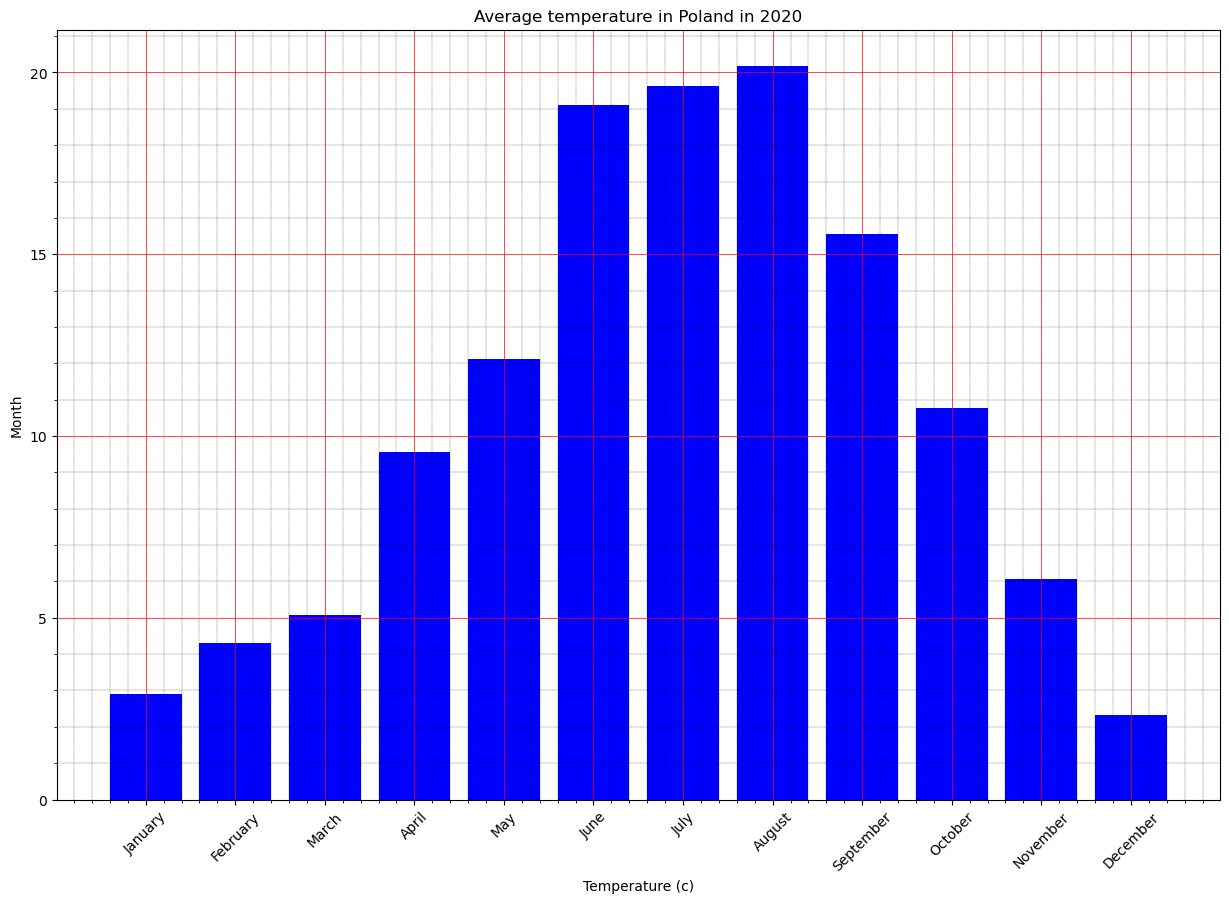

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
 
plt.bar(range(1, 13), df_month_avg['Average temperature'], color='blue')
 
plt.xticks(range(1, 13), months_names, rotation=45)
plt.yticks(range(0, 25, 5))
 
plt.title('Average temperature in Poland in 2020')
 
plt.ylabel('Month')
plt.xlabel('Temperature (c)')
 
plt.minorticks_on()
 
plt.grid(which='major', linestyle='-', linewidth='0.5', color='red')
plt.grid(which='minor', linestyle='--', linewidth='0.2', color='black')

In [4]:
df_nice_days = df.loc[df['Average daily cloud cover [oktas]'] <= 4]
df_bad_days = df.loc[df['Average daily cloud cover [oktas]'] > 4]
 
s_nice_days_per_month = df_nice_days.groupby('Month').size()
s_bad_days_per_month = df_bad_days.groupby('Month').size()

In [13]:
s_nice_days_per_month

Month
1      5
2      7
3     15
4     23
5     13
6     12
7     13
8     19
9     16
10     8
11     4
12     6
dtype: int64

In [12]:
df_nice_days = df.loc[df['Average daily cloud cover [oktas]'] <= 4]
df_nice_days

,Station code,Station name,Year,Month,Day,Average daily temperature,Average daily relative humidity,Average daily wind speed [m/s],Average daily cloud cover [oktas]
4,252200150,WARSZAWA-BIELANY,2020,1,5,0.7,79.5,3.3,0.7
13,252200150,WARSZAWA-BIELANY,2020,1,14,3.8,79.5,2.7,3.0
14,252200150,WARSZAWA-BIELANY,2020,1,15,5.4,61.8,2.7,1.3
15,252200150,WARSZAWA-BIELANY,2020,1,16,5.1,75.8,3.0,1.0
20,252200150,WARSZAWA-BIELANY,2020,1,21,2.1,81.0,5.3,3.3
...,...,...,...,...,...,...,...,...,...
338,252200150,WARSZAWA-BIELANY,2020,12,4,2.7,82.3,5.0,3.7
339,252200150,WARSZAWA-BIELANY,2020,12,5,7.4,76.5,5.0,1.7
341,252200150,WARSZAWA-BIELANY,2020,12,7,1.2,80.5,7.0,3.7
357,252200150,WARSZAWA-BIELANY,2020,12,23,4.8,87.0,2.3,3.7


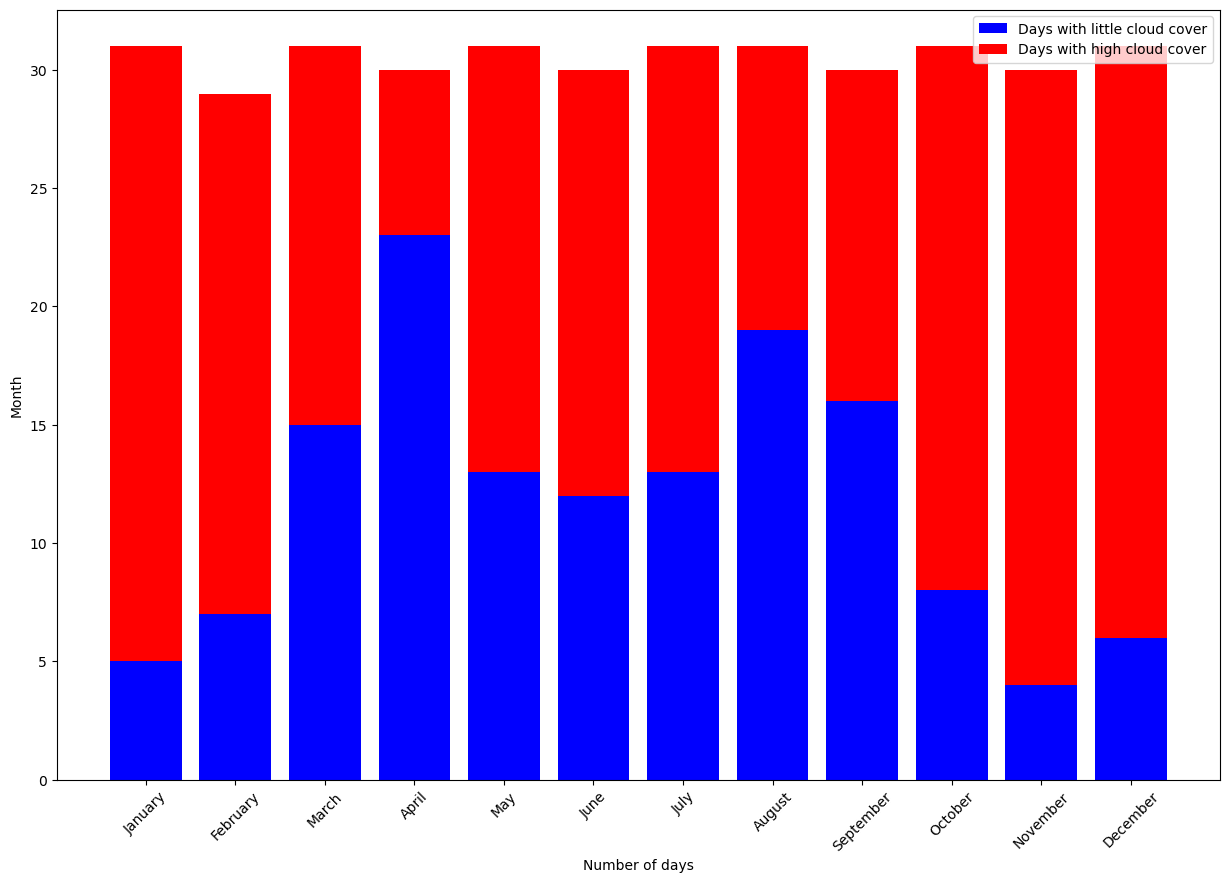

In [5]:
plt.figure(figsize=(15,10))
 
plt.bar(range(1, 13), s_nice_days_per_month, color='blue',
        label='Days with little cloud cover')
plt.bar(range(1, 13), s_bad_days_per_month, color='red',
        bottom=s_nice_days_per_month, label='Days with high cloud cover')
 
plt.xticks(range(1, 13), months_names, rotation=45)
 
plt.ylabel('Month')
plt.xlabel('Number of days')
 
plt.legend()